Biome generation in the Overworld is based on 6 parameters: temperature, humidity (aka. vegetation), continentalness (aka. continents), erosion, weirdness (aka. ridges), and depth. Except for "depth", the other 5 parameters are based only on horizontal coordinates.

They can be thought of as a six-dimensional (6D) space, where multiple intervals are defined for each biome, as described below. If the 6 parameters at a location fall outside all the defined biome intervals, the game uses the closest biome interval in the 6D space.

Temperature is a noise parameter used only in biome generation and does not affect terrain generation. Temperature values are divided into 5 levels. The corresponding ranges from level 0 to level 4 are: -1.0\~-0.45, -0.45\~-0.15, -0.15~~0.2, 0.2~~0.55, 0.55\~1.0.

Note that the temperature parameter is not the same as the temperature property of a biome, but they roughly correspond each other, e.g. if a location's temperature parameter is level 0, the base temperature of the biome here is usually low enough or the terrain is high enough, that the surface is covered in snow and ice.

Humidity (also known as vegetation) is a noise parameter used only in biome generation and does not affect terrain generation. Humidity values are also divided into 5 levels. The corresponding ranges from level 0 to level 4 are: -1.0\~-0.35, -0.35\~-0.1, -0.1~~0.1, 0.1~~0.3, 0.3\~1.0.

Continentalness (also known as continents) is used to decide between ocean/beach/land biomes. Higher values correspond to more inland biomes.

If -1.2\~-1.05: Mushroom fields
If -1.05\~-0.455: Deep ocean
If -0.455\~-0.19: Ocean
If -0.19\~-0.11: Coast
If -0.11~~0.03: Near-inland
If 0.03~~0.3: Mid-inland
If 0.3~~1.0: Far-inland
Erosion is mainly used to decide between flat and mountainous biomes. When erosion is high the landscape is generally flat. Erosion values are divided into 7 levels. The corresponding ranges from level 0 to level 6 are: -1.0~~-0.78, -0.78\~-0.375, -0.375\~-0.2225, -0.2225~~0.05, 0.05~~0.45, 0.45~~0.55, 0.55~~1.0.

Weirdness (also known as ridges) affects whether to generate a biome variant or not. If the weirdness value is greater than 0, the generated biome becomes weirder. For example, using the variant of the Jungle biome — Bamboo Jungle. Additionally, weirdness also affects where peaks and valleys generate. Because of this, a biome and its variant often do not appear on the same bank of a river.

A diagram of peaks and valleys (Y-axis) calculated from weirdness (X-axis).
The PV (peaks and valleys, aka. ridges folded) value is calculated through the formula
1
−
|
(
3
|
w
e
i
r
d
n
e
s
s
|
)
−
2
|
.

If -1.0\~-0.85: Valleys
If -0.85\~-0.6: Low
If -0.6~~0.2: Mid
If 0.2~~0.7: High
If 0.7\~1.0: Peaks
Depth is a parameter not based directly on noise, instead it corresponds approximately to the terrain height. It is roughly 0 at the surface and increases by 1⁄128 (0.0078125) for every 1 block down. The depth parameter affects whether a surface biome or a cave biome is placed.

Here I attached the world preset json definition of my modpack in 1.20 minecraft. In the definition there is an entry called "biomes". It's value is an array of biome with their respective "parameters", which define an interval on a six-dimensional parameter space. There may be multiple intervals-this array is not a unique-key set. I want you to find a way to use Python to read from the json file, and to find a way to visualize these six-dimensional intervals in the best way. Beginning of this json file is like this:

{
"dimensions": {
"minecraft\:overworld": {
"type": "minecraft\:overworld",
"generator": {
"type": "minecraft\:noise",
"biome\_source": {
"type": "minecraft\:multi\_noise",
"biomes": \[
{
"biome": "the\_winter\_rescue\:diorite\_caves",
"parameters": {
"continentalness": \[
0.03,
0.3
],
"depth": \[
0.1,
0.45
],
"erosion": \[
-0.78,
-0.375
],
"humidity": \[
-0.45,
0.4
],
"offset": 0.125,
"temperature": \[
0.05,
0.45
],
"weirdness": \[
-0.78,
-0.2225
]
}
},

Please help me write Python code to help read these biome with parameter intervals into a python data structure for easier manipulation.


In [6]:
import json
from pathlib import Path

import pandas as pd

# ---- 1. load the preset -----------------------------
preset_path = Path("normal.json")        # <-- change if your file is elsewhere
with preset_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

# ---- 2. walk to the biome list ----------------------
biomes = (
    data["dimensions"]
        ["minecraft:overworld"]["generator"]
        ["biome_source"]["biomes"]      # <— this is the big list
)

# ---- 3. flatten each biome entry --------------------
rows = []
for entry in biomes:
    name = entry["biome"]
    par  = entry["parameters"]

    # grab all six noise intervals (+ offset, which appears in many entries)
    rows.append(
        {
            "biome"         : name,
            "temperature_min"       : par["temperature"][0],
            "temperature_max"       : par["temperature"][1],
            "humidity_min"      : par["humidity"][0],
            "humidity_max"      : par["humidity"][1],
            "continentalness_min"       : par["continentalness"][0],
            "continentalness_max"       : par["continentalness"][1],
            "erosion_min"       : par["erosion"][0],
            "erosion_max"       : par["erosion"][1],
            "weirdness_min"      : par["weirdness"][0],
            "weirdness_max"      : par["weirdness"][1],
            "depth_min"      : par["depth"][0],
            "depth_max"      : par["depth"][1],
            "offset"        : par.get("offset", 0.0),   # not always present
        }
    )

df = pd.DataFrame(rows)

# ---- 4. quick sanity check --------------------------
print(df.head())
print("total rows:", len(df))

# You now have a DataFrame `df` you can:
# • query:   df[df["temp_lo"] < -0.5]
# • group:   df.groupby("biome").size()
# • export:  df.to_csv("biome_intervals.csv", index=False)


                                     biome  temperature_min  temperature_max  \
0          the_winter_rescue:diorite_caves             0.05             0.45   
1          the_winter_rescue:diorite_caves             0.05             0.45   
2  the_winter_rescue:hydrothermal_deposits             0.05             0.45   
3      the_winter_rescue:magmatic_deposits             0.25             1.00   
4        the_winter_rescue:fossil_deposits             0.10             0.35   

   humidity_min  humidity_max  continentalness_min  continentalness_max  \
0         -0.45           0.4                 0.03                 0.30   
1         -0.45           0.4                 0.03                 0.30   
2         -0.35           0.3                 0.03                 0.30   
3         -1.00           1.0                 0.03                 1.00   
4         -0.35           0.3                 0.10                 0.45   

   erosion_min  erosion_max  weirdness_min  weirdness_max  depth_min

In [12]:
# Get all unique biome names
unique_biomes = df["biome"].unique()
# Print the unique biome names
print("Unique biomes:")
for biome in unique_biomes:
    print(biome)
# Save the DataFrame to a CSV file
output_csv_path = Path("biome_intervals.csv")
df.to_csv(output_csv_path, index=False)

Unique biomes:
the_winter_rescue:diorite_caves
the_winter_rescue:hydrothermal_deposits
the_winter_rescue:magmatic_deposits
the_winter_rescue:fossil_deposits
the_winter_rescue:brine_deposits
the_winter_rescue:destroyed_forest
the_winter_rescue:ice_caves
minecraft:deep_frozen_ocean
minecraft:frozen_ocean
minecraft:snowy_slopes
minecraft:ice_spikes
minecraft:snowy_plains
minecraft:snowy_taiga
the_winter_rescue:nature/destroyed_marsh
the_winter_rescue:nature/snowy_shrubland
minecraft:snowy_beach
minecraft:badlands
minecraft:grove
the_winter_rescue:nature/frostbough_forest
the_winter_rescue:nature/ironwinter_hollow
the_winter_rescue:nature/glacier
minecraft:jagged_peaks
the_winter_rescue:nature/slabback_massif
the_winter_rescue:nature/scree_pine_grove
minecraft:frozen_river
the_winter_rescue:nature/frostpine_grove
minecraft:frozen_peaks
the_winter_rescue:darkfang_caves
minecraft:dripstone_caves
minecraft:lush_caves
the_winter_rescue:mycelium_caves
the_winter_rescue:andesite_caves
the_winter

In [19]:
df[df["biome"] == "minecraft:dripstone_caves"]

,biome,temperature_min,temperature_max,humidity_min,humidity_max,continentalness_min,continentalness_max,erosion_min,erosion_max,weirdness_min,weirdness_max,depth_min,depth_max,offset
446,minecraft:dripstone_caves,-1.00,1.0,-1.00,1.00,0.80,1.000,-1.0,1.0,-1.0,1.0,0.230,0.95,0.000
451,minecraft:dripstone_caves,-0.15,1.0,-0.36,-0.34,0.05,0.725,-0.3,0.3,-1.0,0.2,0.225,0.90,0.215


In [10]:
import pandas as pd
from itertools import combinations

AXES = [
    ("continentalness_min", "continentalness_max"),
    ("depth_min",          "depth_max"),
    ("erosion_min",        "erosion_max"),
    ("humidity_min",       "humidity_max"),
    ("temperature_min",    "temperature_max"),
    ("weirdness_min",      "weirdness_max"),
]

TOL = 1e-9
MERGE_TOUCHING = True

def _interval_equal(a_min, a_max, b_min, b_max):
    return abs(a_min - b_min) < TOL and abs(a_max - b_max) < TOL

def _interval_contains(big_min, big_max, small_min, small_max):
    return big_min - TOL <= small_min and small_max <= big_max + TOL

def _interval_overlap_or_touch(a_min, a_max, b_min, b_max):
    return (a_min - TOL <= b_max and b_min - TOL <= a_max) or (
        MERGE_TOUCHING and (abs(a_max - b_min) < TOL or abs(b_max - a_min) < TOL)
    )

def compress_biome_intervals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove duplicates, drop rectangles contained in another,
    and greedily merge rectangles that differ on only one axis
    but overlap/touch there.
    """
    out_blocks = []

    for biome, block in df.groupby("biome"):
        # 1. exact duplicates
        block = block.drop_duplicates(subset=sum(AXES, ()))

        # 2. drop contained rectangles
        keep = [True] * len(block)
        rows = block.reset_index(drop=True)
        for i, j in combinations(rows.index, 2):
            if all(
                _interval_contains(rows.loc[i, lo], rows.loc[i, hi],
                                   rows.loc[j, lo], rows.loc[j, hi])
                for lo, hi in AXES
            ):
                keep[j] = False
            elif all(
                _interval_contains(rows.loc[j, lo], rows.loc[j, hi],
                                   rows.loc[i, lo], rows.loc[i, hi])
                for lo, hi in AXES
            ):
                keep[i] = False
        block = rows[keep].copy().reset_index(drop=True)

        # 3. greedy 1‑axis merge
        changed = True
        while changed:
            changed = False
            for i, j in combinations(block.index, 2):
                diff_axes = [
                    k for k, (lo, hi) in enumerate(AXES)
                    if not _interval_equal(block.at[i, lo], block.at[i, hi],
                                           block.at[j, lo], block.at[j, hi])
                ]
                if len(diff_axes) == 1:
                    k = diff_axes[0]
                    lo, hi = AXES[k]
                    if _interval_overlap_or_touch(
                        block.at[i, lo], block.at[i, hi],
                        block.at[j, lo], block.at[j, hi],
                    ):
                        # build merged row
                        new_row = block.loc[i].copy()
                        new_row[lo] = min(block.at[i, lo], block.at[j, lo])
                        new_row[hi] = max(block.at[i, hi], block.at[j, hi])

                        # replace i & j with the merged rectangle
                        block = pd.concat(
                            [block.drop([i, j]), new_row.to_frame().T],
                            ignore_index=True
                        )
                        changed = True
                        break
        out_blocks.append(block)

    return pd.concat(out_blocks, ignore_index=True)



df_raw = df # your DataFrame built from the JSON
df_minimal = compress_biome_intervals(df_raw)
print(len(df_raw), "rows  →  ", len(df_minimal), "rows after compression")

455 rows  →   392 rows after compression


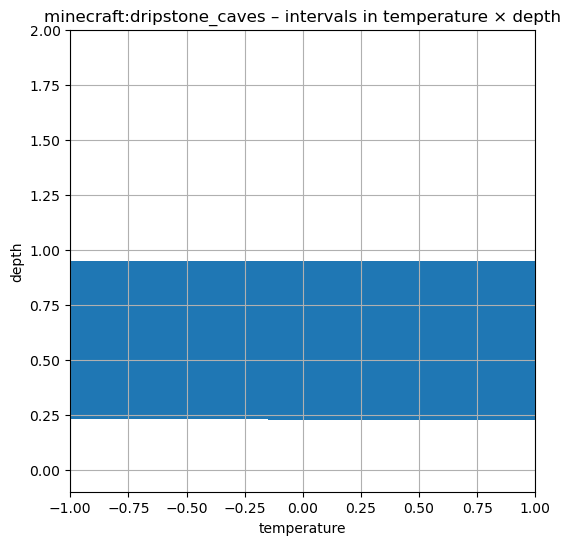

In [28]:
import json, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ────────────────────────────────────────────────────────────
# 1.  Build a DataFrame with one row per biome-interval
# ────────────────────────────────────────────────────────────
def load_biome_df(json_path: str | Path) -> pd.DataFrame:
    with open(json_path, "r") as f:
        data = json.load(f)

    rows = []
    for entry in data["dimensions"]["minecraft:overworld"]["generator"]["biome_source"]["biomes"]:
        row = {"biome": entry["biome"]}
        for key, val in entry["parameters"].items():
            if isinstance(val, list) and len(val) == 2:
                row[f"{key}_min"] = float(val[0])
                row[f"{key}_max"] = float(val[1])
        rows.append(row)

    return pd.DataFrame(rows)

df_biome = load_biome_df("normal.json")

# ────────────────────────────────────────────────────────────
# 2.  Define global parameter axis limits (from Mojang docs)
# ────────────────────────────────────────────────────────────
PARAM_LIMITS = {
    "temperature":    (-1.0,  1.0),
    "humidity":       (-1.0,  1.0),
    "continentalness":(-1.2,  1.0),
    "erosion":        (-1.0,  1.0),
    "weirdness":      (-1.0,  1.0),
    "depth":          (-0.1, 2.0),       # practical range in the preset
}

# ────────────────────────────────────────────────────────────
# 3.  Visualiser
# ────────────────────────────────────────────────────────────
def plot_biome_intervals(biome_id: str, x_param: str, y_param: str):
    """
    Draws 2-D rectangles for all intervals of `biome_id`
    along the two chosen noise parameters.
    """
    subset = df_biome[df_biome["biome"] == biome_id]
    if subset.empty:
        raise ValueError(f"No rows found for biome '{biome_id}'")

    x_lo, x_hi = (f"{x_param}_min", f"{x_param}_max")
    y_lo, y_hi = (f"{y_param}_min", f"{y_param}_max")
    if x_lo not in subset.columns or y_lo not in subset.columns:
        raise ValueError("Parameter name typo or not present in JSON")

    # ── plot ──
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    for _, row in subset.iterrows():
        rect = Rectangle(
            (row[x_lo], row[y_lo]), 
            row[x_hi] - row[x_lo], 
            row[y_hi] - row[y_lo],
            fill=True                 # outlined rectangles
        )
        ax.add_patch(rect)

    # axis limits
    ax.set_xlim(*PARAM_LIMITS[x_param])
    ax.set_ylim(*PARAM_LIMITS[y_param])

    ax.set_xlabel(x_param)
    ax.set_ylabel(y_param)
    ax.set_title(f"{biome_id} – intervals in {x_param} × {y_param}")
    ax.set_aspect("auto")
    plt.grid(True)
    plt.show()

# ────────────────────────────────────────────────────────────
# 4.  Demo – grove: erosion vs temperature
# ────────────────────────────────────────────────────────────
plot_biome_intervals("minecraft:dripstone_caves", "temperature", "depth")


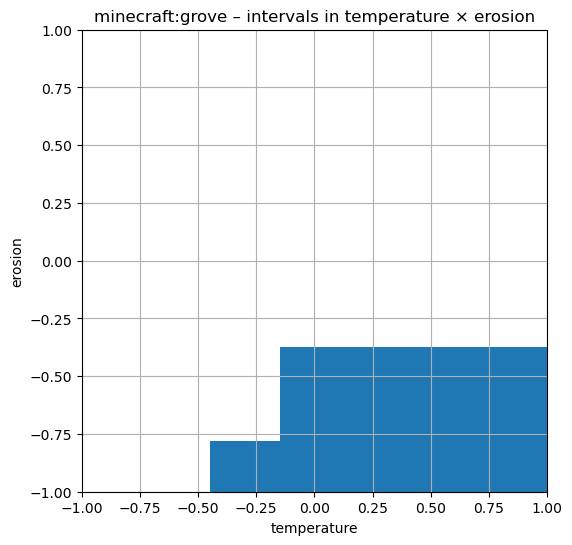

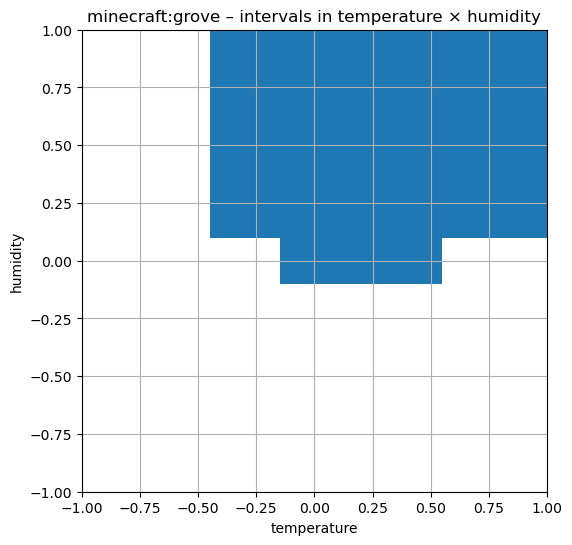

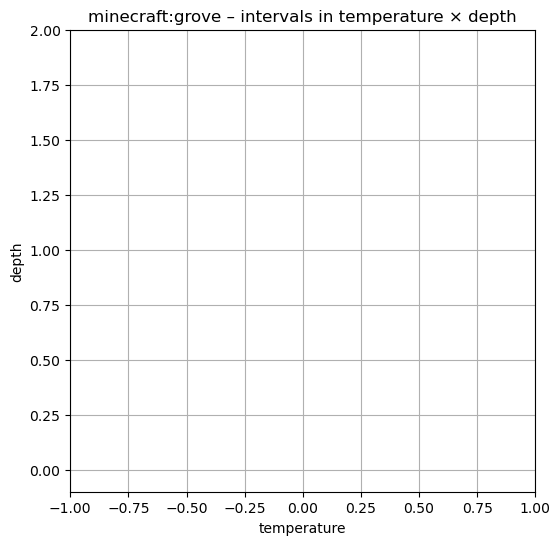

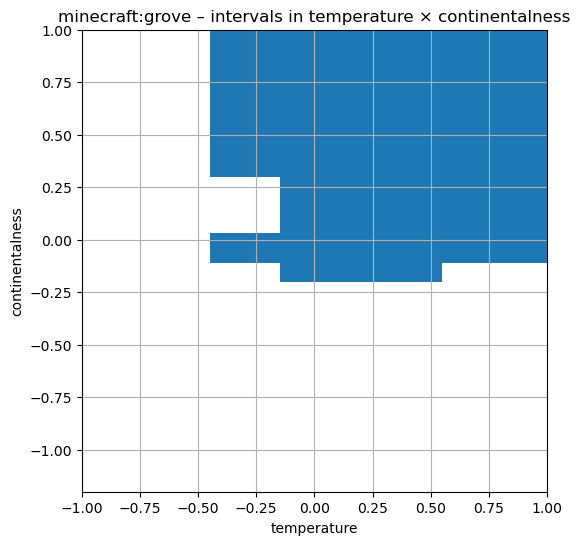

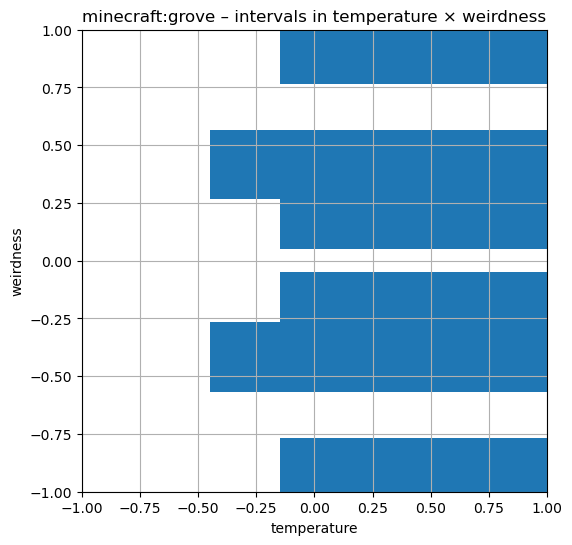

In [29]:
plot_biome_intervals("minecraft:grove", "temperature", "erosion")
plot_biome_intervals("minecraft:grove", "temperature", "humidity")
plot_biome_intervals("minecraft:grove", "temperature", "depth")
plot_biome_intervals("minecraft:grove", "temperature", "continentalness")
plot_biome_intervals("minecraft:grove", "temperature", "weirdness")

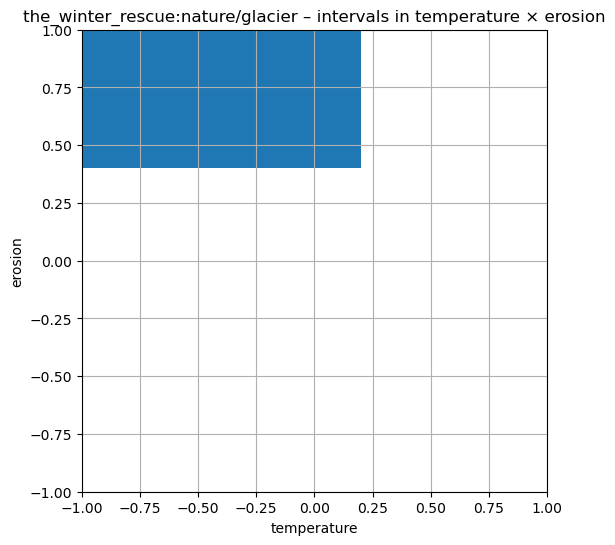

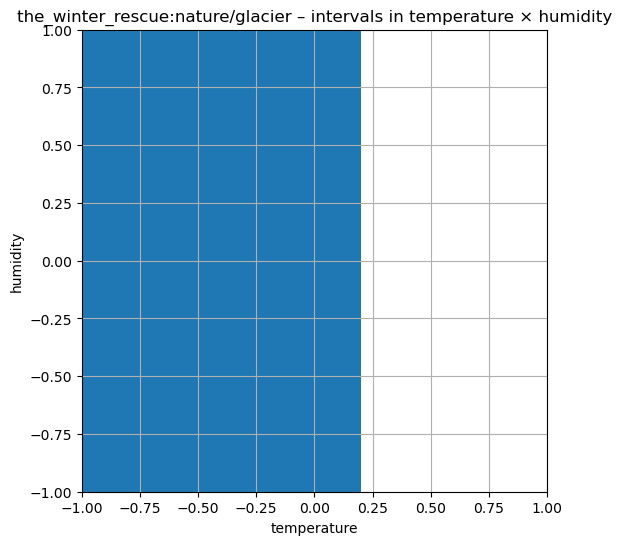

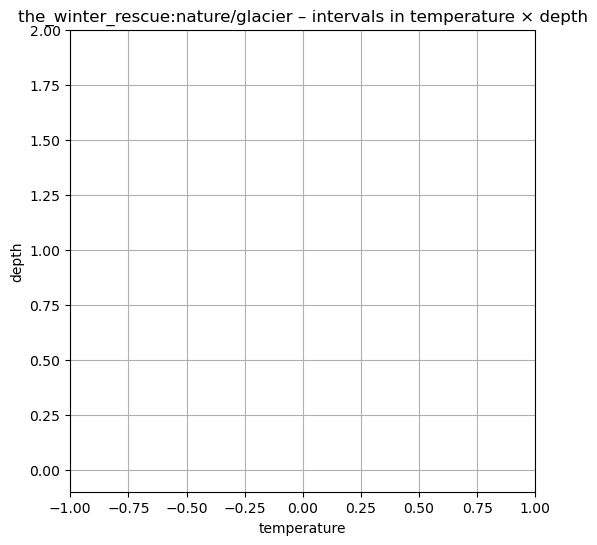

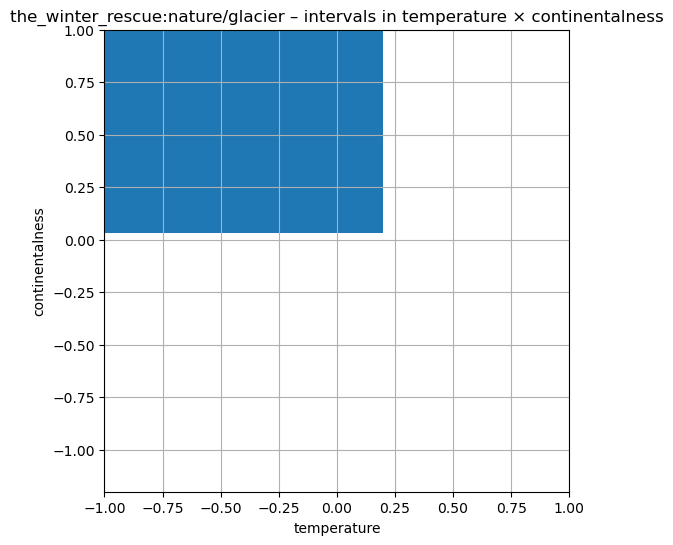

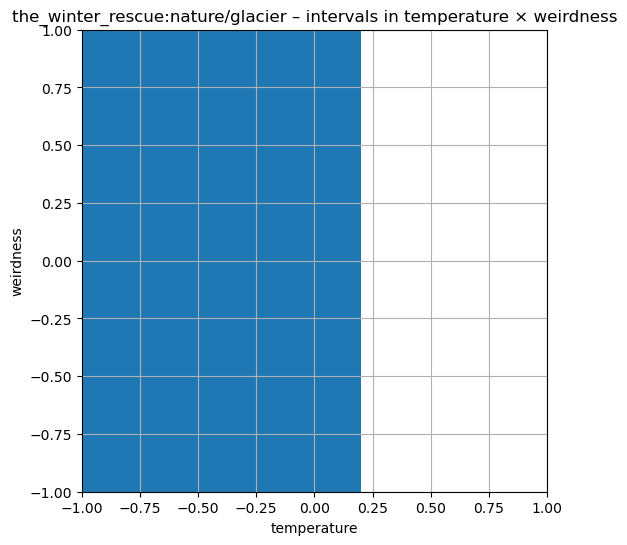

In [30]:
# other examples
plot_biome_intervals("the_winter_rescue:nature/glacier", "temperature", "erosion")
plot_biome_intervals("the_winter_rescue:nature/glacier", "temperature", "humidity")
plot_biome_intervals("the_winter_rescue:nature/glacier", "temperature", "depth")
plot_biome_intervals("the_winter_rescue:nature/glacier", "temperature", "continentalness")
plot_biome_intervals("the_winter_rescue:nature/glacier", "temperature", "weirdness")


In [31]:
def plot_biome(biome):
    plot_biome_intervals(biome, "temperature", "erosion")
    plot_biome_intervals(biome, "temperature", "humidity")
    plot_biome_intervals(biome, "temperature", "depth")
    plot_biome_intervals(biome, "temperature", "continentalness")
    plot_biome_intervals(biome, "temperature", "weirdness")

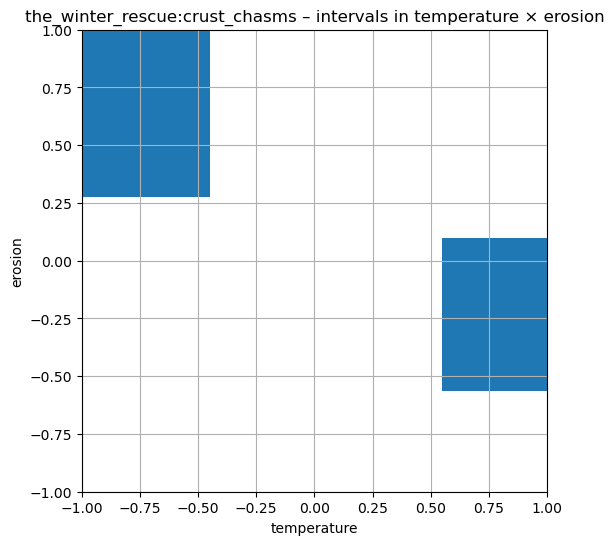

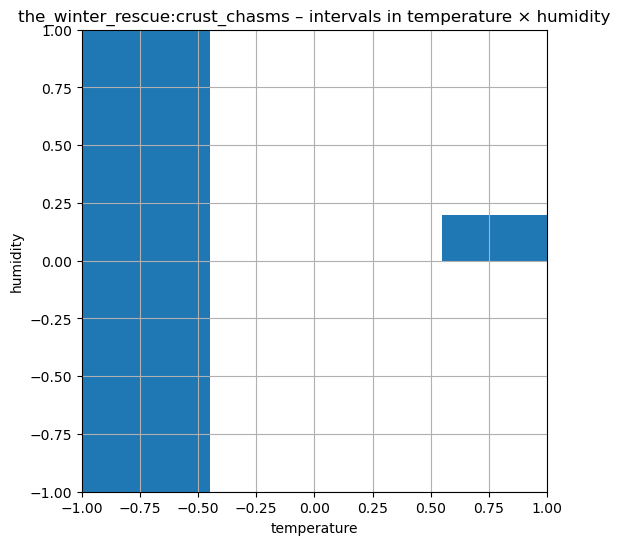

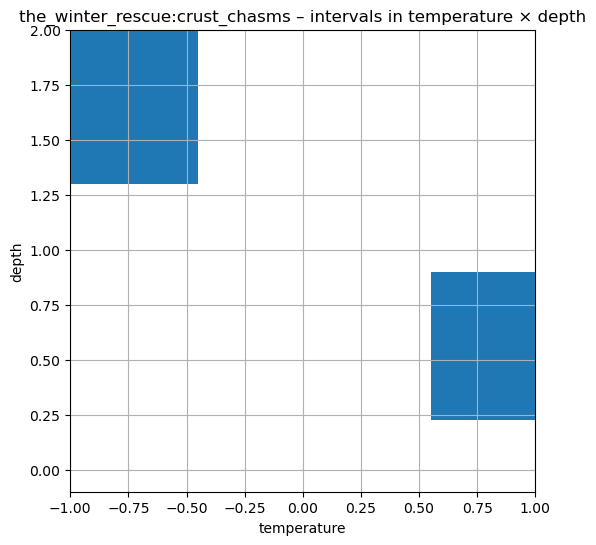

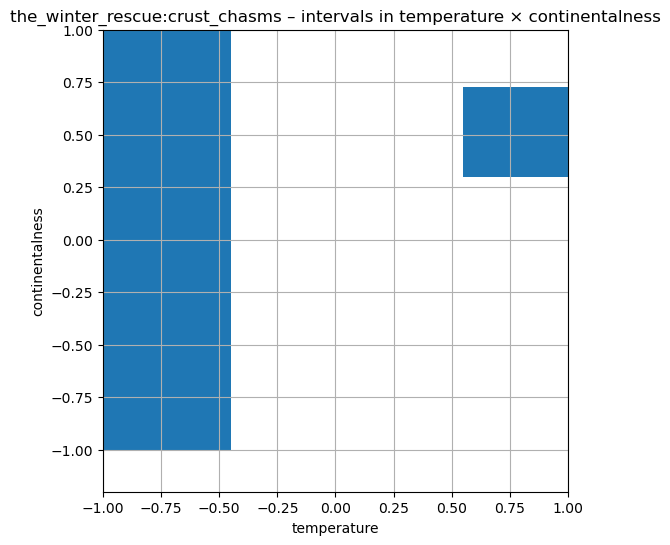

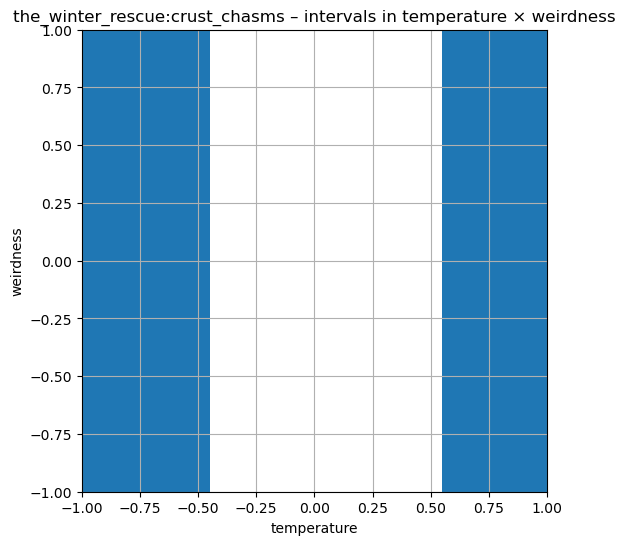

In [32]:
plot_biome("the_winter_rescue:crust_chasms")

/var/folders/mb/f1_g1g0n1s13vfylsby2v1bm0000gn/T/ipykernel_8788/1911676516.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(biomes))  # up to 20 unique colours; cycles thereafter


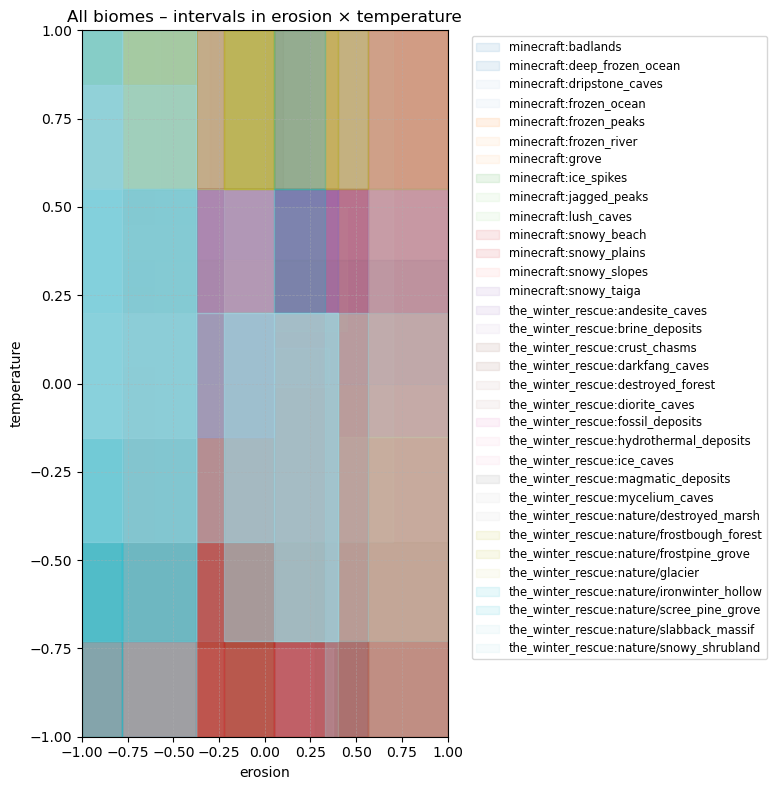

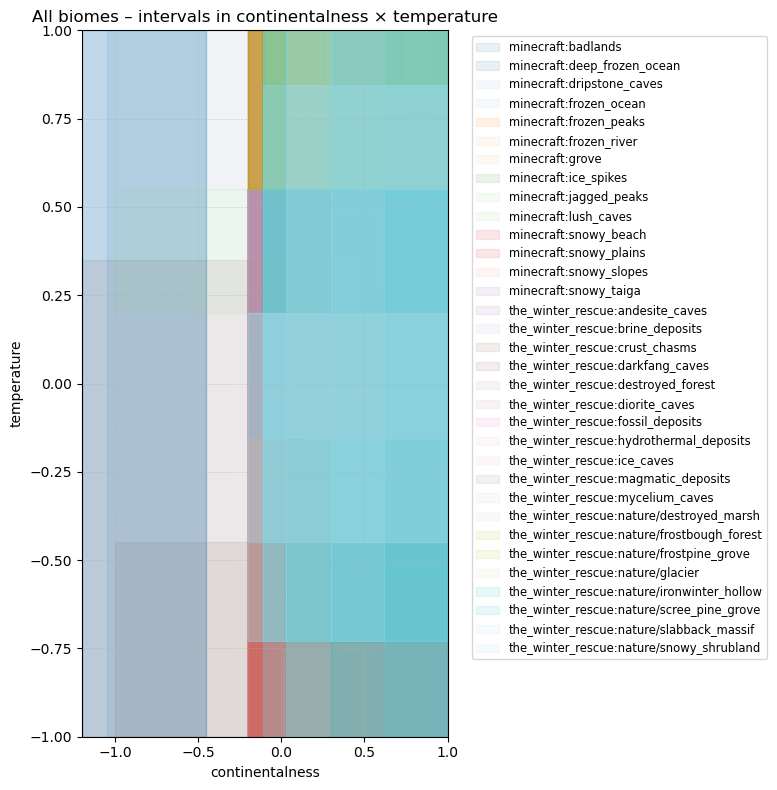

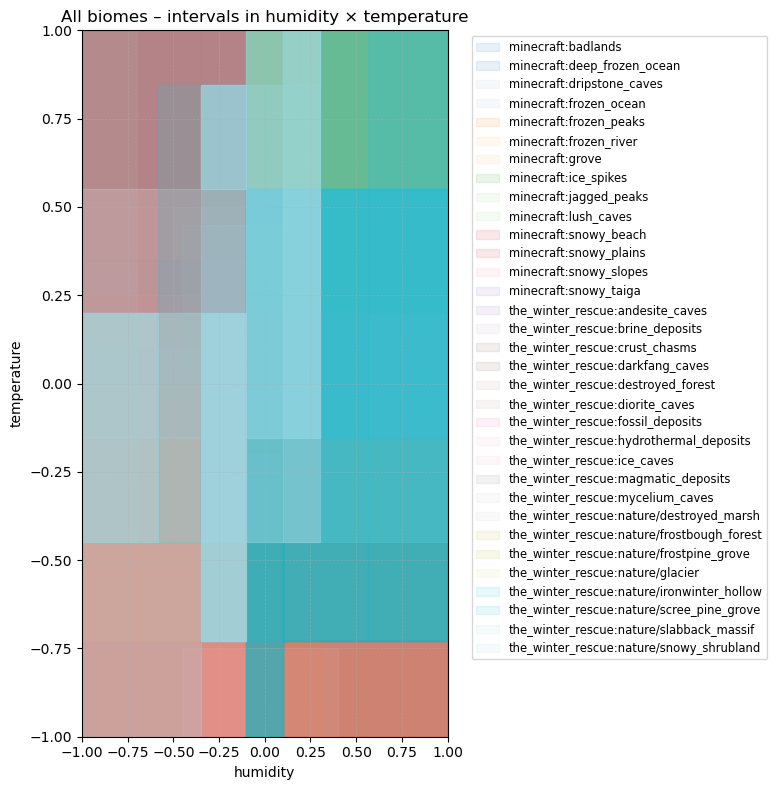

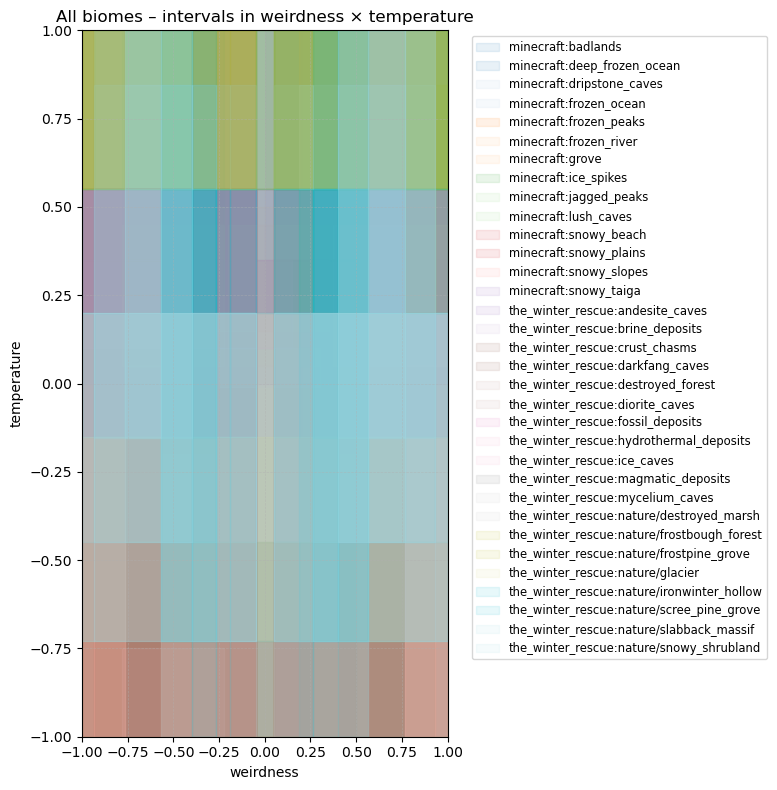

In [39]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import numpy as np

# If df_biome and PARAM_LIMITS already exist from previous cell, we reuse them.
# Otherwise, you'd call load_biome_df("path/to/normal.json") first.

def plot_all_biomes_intervals(x_param: str, y_param: str, alpha: float = 0.1):
    """
    Draws half-transparent rectangles for *every* biome in the DataFrame
    along the chosen pair of noise parameters.

    Parameters
    ----------
    x_param, y_param : str
        Names of the two parameters (temperature, humidity, erosion, ...)
    alpha : float
        Transparency for the rectangles (default 0.4)
    """
    required_cols = [f"{x_param}_min", f"{x_param}_max",
                     f"{y_param}_min", f"{y_param}_max"]
    for col in required_cols:
        if col not in df_biome.columns:
            raise ValueError(f"Column {col!r} not found. "
                             "Check parameter names and DataFrame.")

    # Unique biomes and colour map
    biomes = sorted(df_biome["biome"].unique())
    cmap = cm.get_cmap("tab20", len(biomes))  # up to 20 unique colours; cycles thereafter

    plt.figure(figsize=(8, 8))
    ax = plt.gca()

    for idx, biome in enumerate(biomes):
        subset = df_biome[df_biome["biome"] == biome]
        colour = cmap(idx % cmap.N)

        for _, row in subset.iterrows():
            rect = Rectangle(
                (row[f"{x_param}_min"], row[f"{y_param}_min"]),
                row[f"{x_param}_max"] - row[f"{x_param}_min"],
                row[f"{y_param}_max"] - row[f"{y_param}_min"],
                facecolor=colour,
                edgecolor=colour,
                alpha=alpha,
                label=biome if _ == subset.index[0] else None  # one legend entry per biome
            )
            ax.add_patch(rect)

    ax.set_xlim(*PARAM_LIMITS[x_param])
    ax.set_ylim(*PARAM_LIMITS[y_param])
    ax.set_xlabel(x_param)
    ax.set_ylabel(y_param)
    ax.set_title(f"All biomes – intervals in {x_param} × {y_param}")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    # Compact legend outside plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", ncol=1)
    plt.tight_layout()
    plt.show()

# ────────────────────────────────────────────────────────────
# Demo: show every biome's erosion × temperature rectangles
# (This will be busy but demonstrates the function.)
# ────────────────────────────────────────────────────────────
plot_all_biomes_intervals("erosion", "temperature")
plot_all_biomes_intervals("continentalness", "temperature")
plot_all_biomes_intervals("humidity", "temperature")
plot_all_biomes_intervals("weirdness", "temperature")


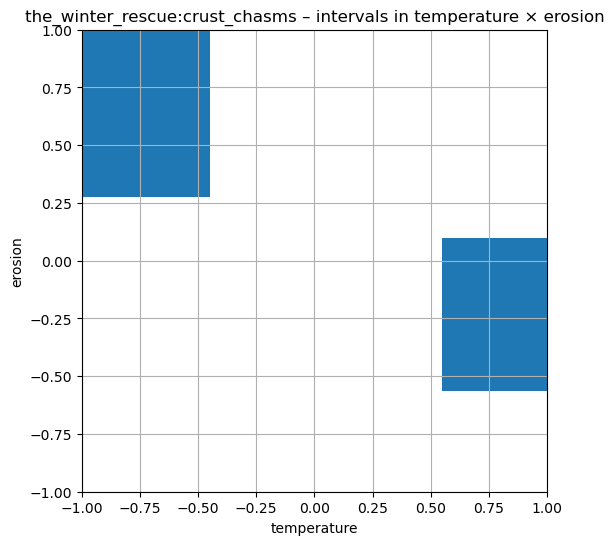

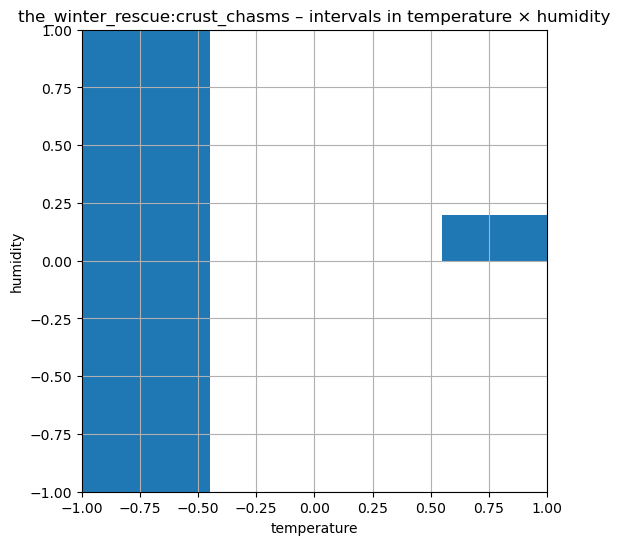

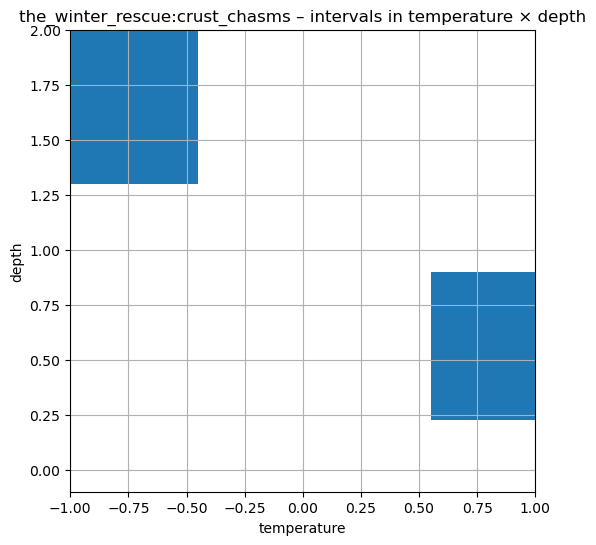

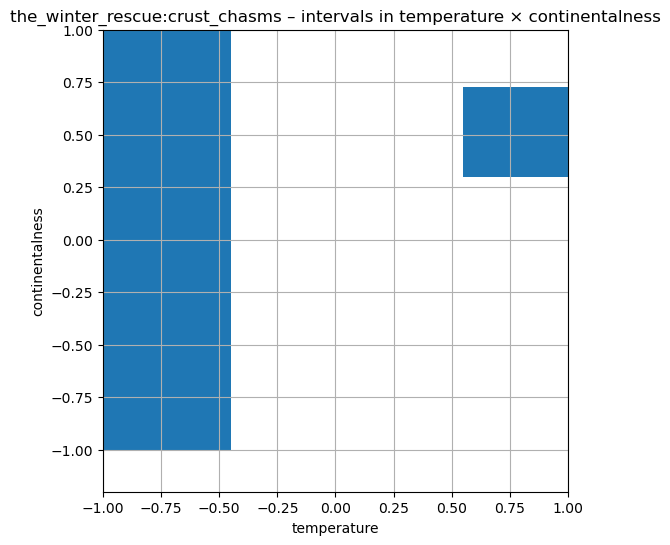

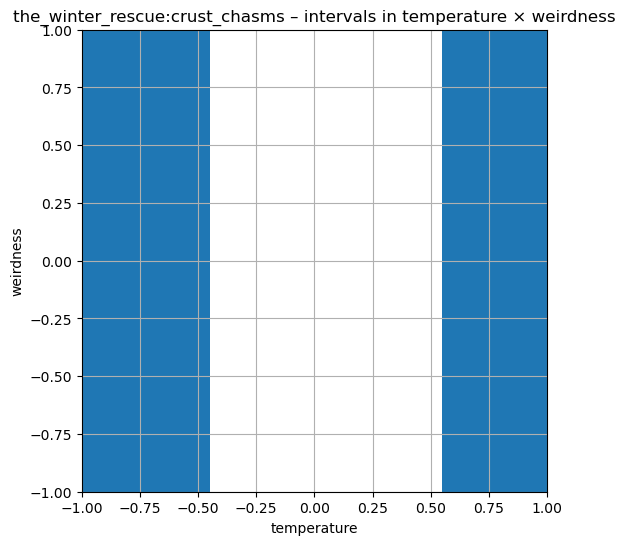

In [40]:
plot_biome("the_winter_rescue:crust_chasms")